In [1]:
# ====================================
# PHASE 1: DATA ANALYTICS & PROCESSING
# ==========================================

# Step 1: Data Ingestion & Structural Validation (Loading the data & checking shape):
import pandas as pd

# 1. Load the dataset (Since files are in the same folder, this is super clean!)
print("Loading data...")
data_main = pd.read_excel('PCOS_data_without_infertility.xlsx', sheet_name='Full_new')
data_inf = pd.read_csv('PCOS_infertility.csv')

# 2. Fix IDs and Merge (Combining the two hospital files)
data_main['Patient File No.'] = pd.to_numeric(data_main['Patient File No.'], errors='coerce')
data_inf['Patient File No.'] = pd.to_numeric(data_inf['Patient File No.'], errors='coerce')
data_inf['Patient File No.'] = data_inf['Patient File No.'] - 10000

# Merge into our master dataframe 'df'
df = pd.merge(data_main, data_inf, on='Patient File No.', suffixes=('', '_drop'))
df.drop([col for col in df.columns if 'drop' in col], axis=1, inplace=True)

# 3. Basic Information
print("\n--- 1. DATASET SHAPE ---")
print(f"Total Patients (Rows): {df.shape[0]}")
print(f"Total Medical Features (Columns): {df.shape[1]}")

print("\n--- 2. FIRST 5 PATIENTS ---")
display(df.head())

# 4. Exploratory Checks
print("\n--- 3. DATA TYPES (Are there hidden typos?) ---")
df.info()

print("\n--- 4. MISSING VALUES CHECK ---")
print(df.isnull().sum().sort_values(ascending=False).head(5))

print(f"\n--- 5. DUPLICATE ROW CHECK ---")
print(f"Total exact duplicate patients: {df.duplicated().sum()}")

# Check if the 45th ghost column exists and drop it
print(f"Columns before check: {df.shape[1]}")

# This code specifically looks for any column containing the word 'Unnamed' and deletes it
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(f"Columns after check: {df.shape[1]}")
print("Ghost columns successfully removed.")

Loading data...

--- 1. DATASET SHAPE ---
Total Patients (Rows): 541
Total Medical Features (Columns): 45

--- 2. FIRST 5 PATIENTS ---


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN



--- 3. DATA TYPES (Are there hidden typos?) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float6

In [2]:
#Step 2: Data Preprocessing & Cleaning (Dropping duplicates, fixing typos, median imputation):

import pandas as pd

print("--- STEP 2: DATA PREPROCESSING & CLEANING INITIALIZED ---")

# 1. Deduplication
initial_observations = df.shape[0]
df = df.drop_duplicates()
print(f"[*] Deduplication: Removed {initial_observations - df.shape[0]} duplicate observations.")

# 2. Data Type Casting (Handling non-numeric artifacts)
# Coercing invalid string entries (e.g., punctuation) to NaN for downstream imputation
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Missing Value Handling (Median Imputation Strategy)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 4. Data Integrity Verification
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"[*] Integrity Check: Non-numeric features remaining: {len(non_numeric_cols)}")
print(f"[*] Integrity Check: Maximum missing values in any feature: {df.isnull().sum().max()}")
print(f"[*] Final dataset shape ready for modeling: {df.shape}")

--- STEP 2: DATA PREPROCESSING & CLEANING INITIALIZED ---
[*] Deduplication: Removed 0 duplicate observations.
[*] Integrity Check: Non-numeric features remaining: 0
[*] Integrity Check: Maximum missing values in any feature: 0
[*] Final dataset shape ready for modeling: (541, 44)


--- FEATURE DISTRIBUTIONS & CLASS IMBALANCE ---


C:\Users\acer\AppData\Local\Temp\ipykernel_20388\752962260.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PCOS (Y/N)', ax=axes[0], palette='viridis')
C:\Users\acer\AppData\Local\Temp\ipykernel_20388\752962260.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-PCOS (0)', 'PCOS (1)'])
C:\Users\acer\AppData\Local\Temp\ipykernel_20388\752962260.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PCOS (Y/N)', y='Follicle No. (R)', ax=axes[1], palette='Set2')
C:\Users\acer\AppData\Local\Temp\ipykernel_20388\752962260.py:22: UserWarning: set_ticklabe

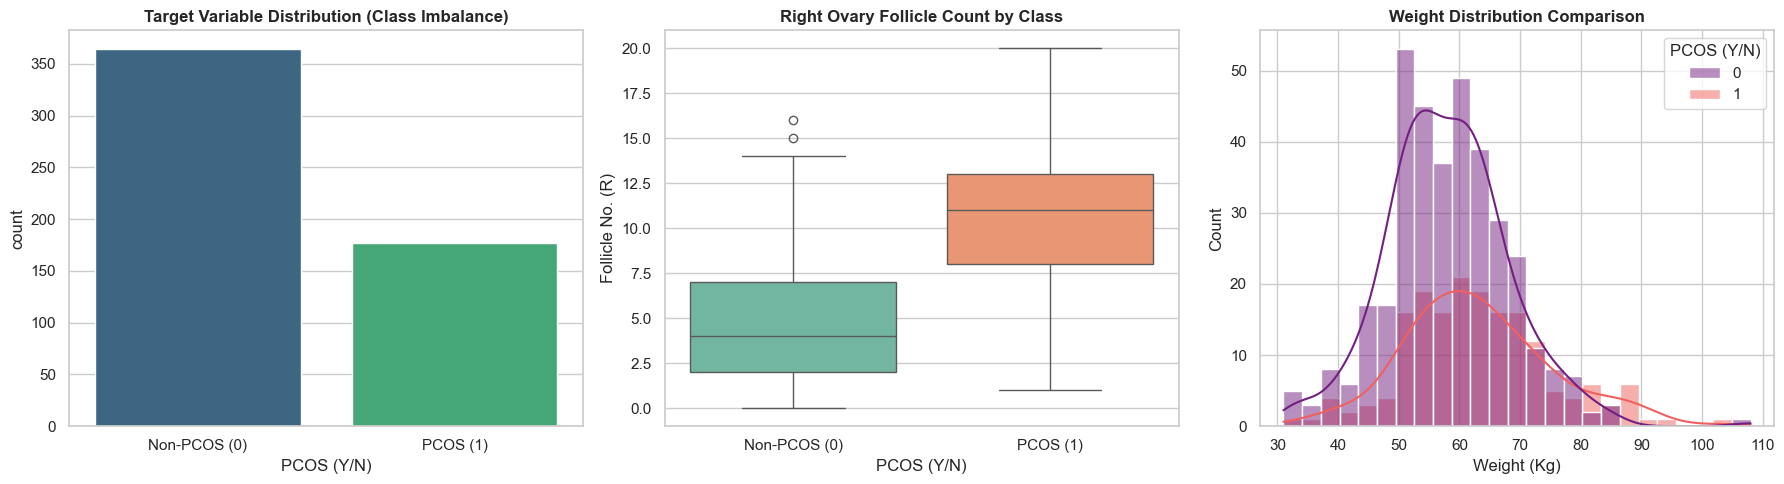


[*] Class Distribution Breakdown:
    Healthy Patients (Class 0): 364
    PCOS Patients (Class 1): 177
    Imbalance Ratio: 2.06 to 1
--- FEATURE CORRELATION ANALYSIS ---

[*] Top 10 Clinical Indicators of PCOS (Pearson Score):
    -> Follicle No. (R): 0.648
    -> Follicle No. (L): 0.603
    -> Skin darkening (Y/N): 0.476
    -> hair growth(Y/N): 0.465
    -> Weight gain(Y/N): 0.441
    -> Cycle(R/I): 0.402
    -> Fast food (Y/N): 0.376
    -> Pimples(Y/N): 0.286
    -> AMH(ng/mL): 0.264
    -> Weight (Kg): 0.212

[*] Heatmap visualization generated successfully.


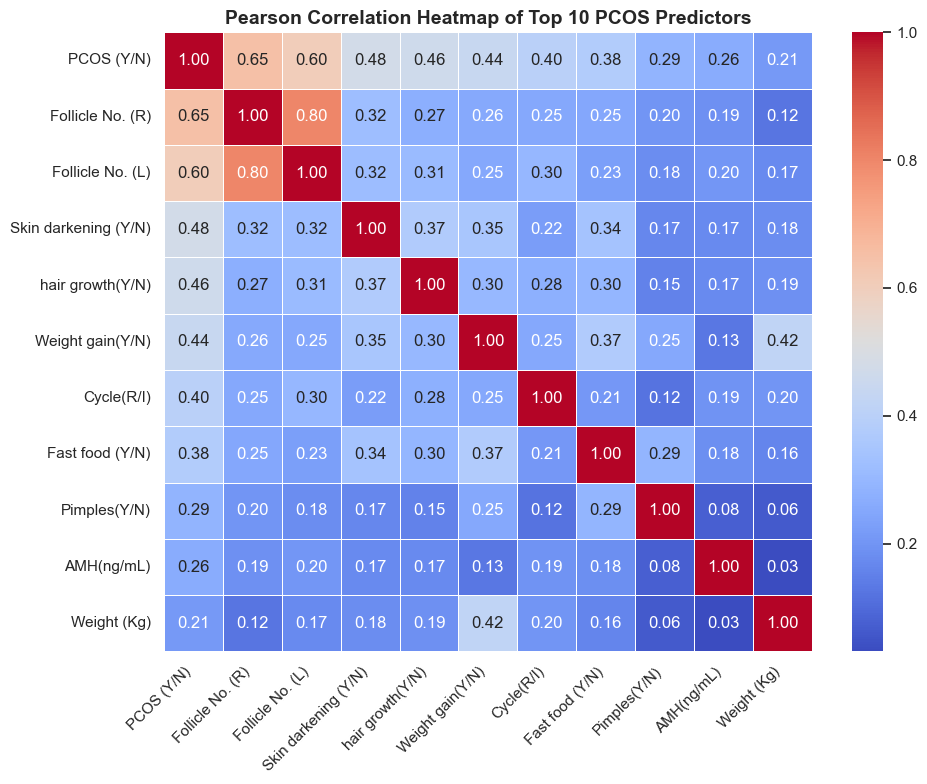

In [3]:
# Step 3: Exploratory Data Analysis (EDA) (Heatmaps, histograms, and class imbalance checks):

import seaborn as sns
import matplotlib.pyplot as plt

print("--- FEATURE DISTRIBUTIONS & CLASS IMBALANCE ---")

# Set the visual style for publication-quality charts
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution of the Target Variable
# This checks if we have an equal number of PCOS and Non-PCOS patients
sns.countplot(data=df, x='PCOS (Y/N)', ax=axes[0], palette='viridis')
axes[0].set_title("Target Variable Distribution (Class Imbalance)", fontweight='bold')
axes[0].set_xticklabels(['Non-PCOS (0)', 'PCOS (1)'])

# 2. Boxplot: Follicle Count vs Diagnosis 
# Follicle number is usually the strongest predictor of PCOS
sns.boxplot(data=df, x='PCOS (Y/N)', y='Follicle No. (R)', ax=axes[1], palette='Set2')
axes[1].set_title("Right Ovary Follicle Count by Class", fontweight='bold')
axes[1].set_xticklabels(['Non-PCOS (0)', 'PCOS (1)'])

# 3. Histogram: Weight Distribution
sns.histplot(data=df, x='Weight (Kg)', hue='PCOS (Y/N)', kde=True, ax=axes[2], palette='magma')
axes[2].set_title("Weight Distribution Comparison", fontweight='bold')

plt.tight_layout()
plt.show()

# Print the exact mathematical imbalance for our documentation
pcos_counts = df['PCOS (Y/N)'].value_counts()
print("\n[*] Class Distribution Breakdown:")
print(f"    Healthy Patients (Class 0): {pcos_counts[0]}")
print(f"    PCOS Patients (Class 1): {pcos_counts[1]}")
print(f"    Imbalance Ratio: {round(pcos_counts[0]/pcos_counts[1], 2)} to 1")

# Correlation Heatmap & Feature Selection

import seaborn as sns
import matplotlib.pyplot as plt

print("--- FEATURE CORRELATION ANALYSIS ---")

# 1. Calculate Pearson correlation against the target variable
correlation_matrix = df.corr()

# 2. Extract the top 10 most highly correlated features
# We take the top 11, because the target correlates with itself at 1.0
top_features_series = correlation_matrix['PCOS (Y/N)'].sort_values(ascending=False).head(11)
top_feature_names = top_features_series.index

# 3. Explicitly print the Top 10 Features and their mathematical scores
print("\n[*] Top 10 Clinical Indicators of PCOS (Pearson Score):")
for feature, score in top_features_series.items():
    if feature != 'PCOS (Y/N)':
        # This prints the feature name and rounds the score to 3 decimal places
        print(f"    -> {feature}: {score:.3f}")

# 4. Visualize the matrix using a Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_feature_names].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 5. Format the plot for publication
plt.title("Pearson Correlation Heatmap of Top 10 PCOS Predictors", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

print("\n[*] Heatmap visualization generated successfully.")
plt.show()

In [4]:
# ==========================================
# PHASE 2: MACHINE LEARNING ENGINE
# ==========================================

# Step 1: Data Partitioning (Train/Test Split):

from sklearn.model_selection import train_test_split

print("--- STEP 1: MODELING PIPELINE INITIALIZED ---")
print("Executing Train/Test Split...")

# 1. Define Feature Matrix (X) and Target Vector (y)
# We drop 'PCOS (Y/N)' because it is the target.
# We drop 'Patient File No.' because an ID number has no biological value.
X = df.drop(columns=['PCOS (Y/N)', 'Patient File No.', 'Sl. No'])
y = df['PCOS (Y/N)']

# 2. Perform 80/20 Split
# stratify=y ensures the exact same ratio of healthy/PCOS patients is kept in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Validation Output
print(f"[*] Original Dataset: {X.shape[0]} total observations")
print(f"[*] Training Set (X_train): {X_train.shape[0]} observations (80%)")
print(f"[*] Testing Set (X_test): {X_test.shape[0]} observations (20%)")
print("[*] Data partitioning completed successfully.")

--- STEP 1: MODELING PIPELINE INITIALIZED ---
Executing Train/Test Split...
[*] Original Dataset: 541 total observations
[*] Training Set (X_train): 432 observations (80%)
[*] Testing Set (X_test): 109 observations (20%)
[*] Data partitioning completed successfully.


In [5]:
# Step 2: Handling Class Imbalance (SMOTE):

from imblearn.over_sampling import SMOTE
import pandas as pd

print("--- STEP 2: APPLYING SMOTE ---")
# Displaying the imbalance before SMOTE
print(f"[*] Original Training Target Distribution:\n{y_train.value_counts()}\n")

# 1. Initialize and apply SMOTE strictly to the Training Set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2. Validation Output
print(f"[*] New Training Target Distribution (After SMOTE):\n{y_train_smote.value_counts()}\n")
print(f"[*] Training Features Matrix Shape: {X_train_smote.shape}")
print("[*] SMOTE application completed successfully.")

--- STEP 2: APPLYING SMOTE ---
[*] Original Training Target Distribution:
PCOS (Y/N)
0    291
1    141
Name: count, dtype: int64

[*] New Training Target Distribution (After SMOTE):
PCOS (Y/N)
0    291
1    291
Name: count, dtype: int64

[*] Training Features Matrix Shape: (582, 41)
[*] SMOTE application completed successfully.


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [6]:
# Step 3: Feature Scaling (Standardization):

from sklearn.preprocessing import StandardScaler
import pandas as pd

print("--- STEP 3: FEATURE SCALING INITIALIZED ---")

# 1. Initialize the StandardScaler
# This transforms data so every column has a mean of 0 and a standard deviation of 1
scaler = StandardScaler()

# 2. Fit and Transform the Training Data
# The scaler "learns" the mathematical boundaries from the training data ONLY.
X_train_scaled = scaler.fit_transform(X_train_smote)

# 3. Transform the Testing Data
# The scaler applies the EXACT SAME math to the test data without learning from it.
# This strictly prevents Data Leakage.
X_test_scaled = scaler.transform(X_test)

# 4. Convert arrays back to DataFrames to retain column names for later analysis
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("[*] Feature scaling applied successfully using StandardScaler.")
print(f"[*] Scaled Training Matrix Shape: {X_train_scaled.shape}")
print(f"[*] Scaled Testing Matrix Shape: {X_test_scaled.shape}")

--- STEP 3: FEATURE SCALING INITIALIZED ---
[*] Feature scaling applied successfully using StandardScaler.
[*] Scaled Training Matrix Shape: (582, 41)
[*] Scaled Testing Matrix Shape: (109, 41)


--- COMPREHENSIVE MODEL EVALUATION ---

[*] Algorithm Performance Comparison Table:


,Algorithm,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.8899,0.8333,0.8333,0.8333
0,Logistic Regression,0.8624,0.7442,0.8889,0.8101
1,Decision Tree,0.8257,0.7297,0.7500,0.7397
3,K-Nearest Neighbors,0.7890,0.6226,0.9167,0.7416


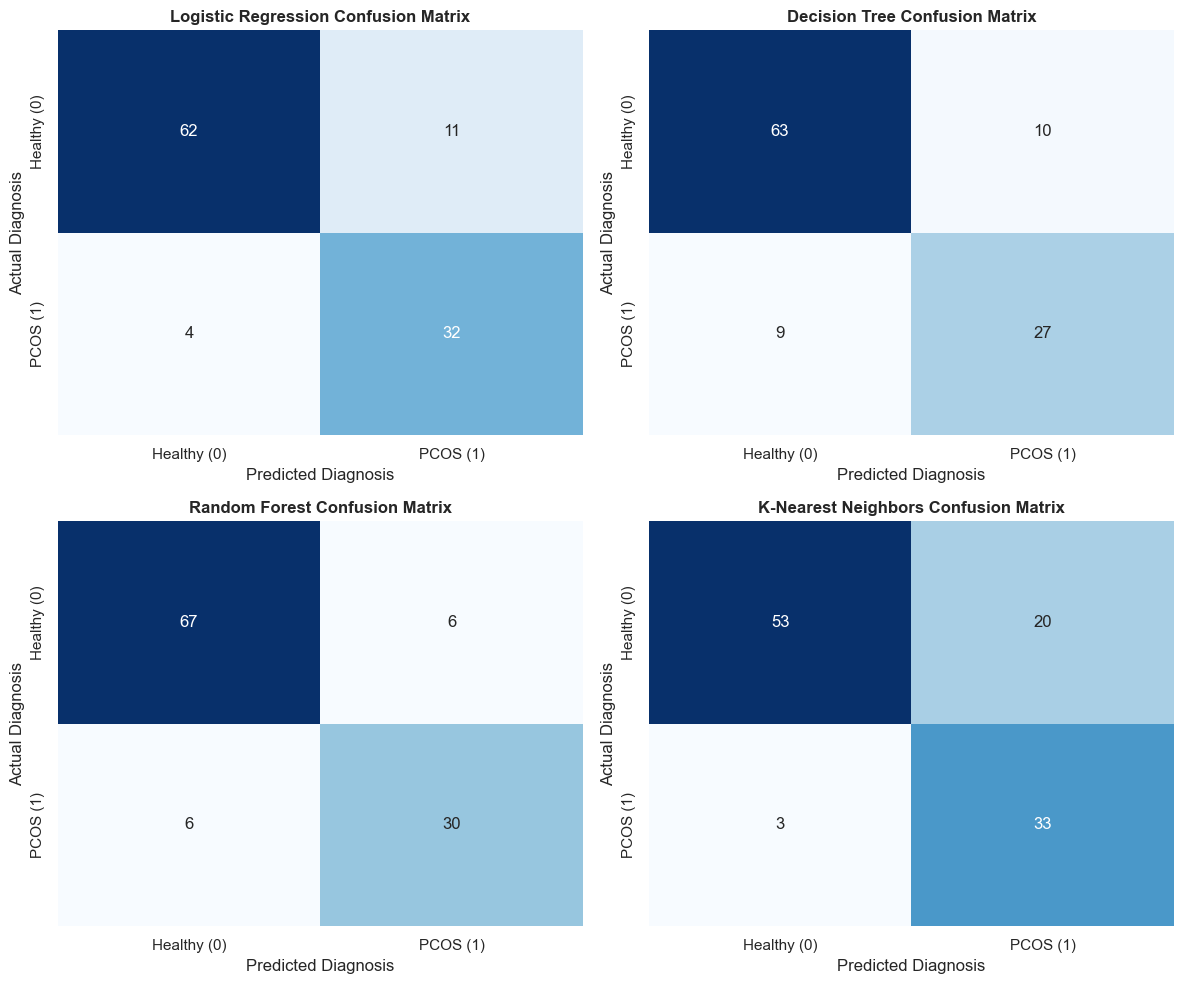

[*] Comprehensive evaluation completed successfully.


In [7]:
# Step 4: Model Training & Advanced Evaluation:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- COMPREHENSIVE MODEL EVALUATION ---")

# 1. Initialize the specific classification algorithms
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Dictionaries to store results
evaluation_metrics = []
confusion_matrices = {}

# 2. Train and Evaluate each model
for name, model in models.items():
    # Train on balanced/scaled data
    model.fit(X_train_scaled, y_train_smote)
    
    # Predict on unseen test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate advanced medical metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Store metrics for the comparison table
    evaluation_metrics.append({
        "Algorithm": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4)
    })
    
    # Store confusion matrix for visualization
    confusion_matrices[name] = cm

# 3. Present Results in a Comparison Table
results_df = pd.DataFrame(evaluation_metrics).sort_values(by="Accuracy", ascending=False)
print("\n[*] Algorithm Performance Comparison Table:")
# Printing the DataFrame directly creates a clean table in Jupyter
display(results_df)

# 4. Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 grid to easily loop through it

for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Healthy (0)', 'PCOS (1)'], 
                yticklabels=['Healthy (0)', 'PCOS (1)'])
    axes[i].set_title(f"{name} Confusion Matrix", fontweight='bold')
    axes[i].set_xlabel('Predicted Diagnosis')
    axes[i].set_ylabel('Actual Diagnosis')

plt.tight_layout()
plt.show()

print("[*] Comprehensive evaluation completed successfully.")

--- ROC-AUC CURVE ANALYSIS ---


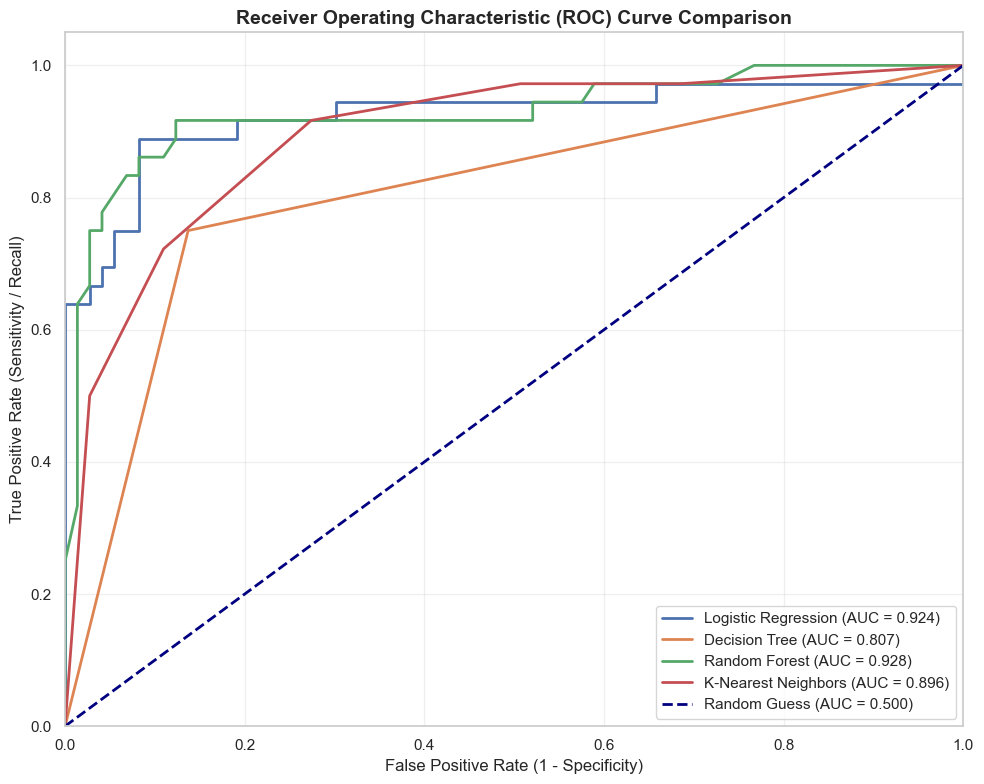

[*] ROC-AUC Analysis completed successfully.


In [8]:
# Step 5: ROC-AUC Curve Analysis:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("--- ROC-AUC CURVE ANALYSIS ---")

# 1. Initialize the plot canvas
plt.figure(figsize=(10, 8))

# 2. Loop through the trained models from the previous cell
# We use predict_proba() to get the actual mathematical confidence (0% to 100%) of the diagnosis
for name, model in models.items():
    # Get probability scores for the positive class (PCOS = 1)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    
    # Calculate Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve for this specific algorithm
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# 3. Plot the 'Random Guess' baseline (the diagonal dashed line)
# If a model falls on this line, it is no better than flipping a coin
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

# 4. Format the chart for professional publication
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("[*] ROC-AUC Analysis completed successfully.")

--- EXTRACTING CLINICAL FEATURE IMPORTANCE ---


C:\Users\acer\AppData\Local\Temp\ipykernel_20388\1552231639.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')


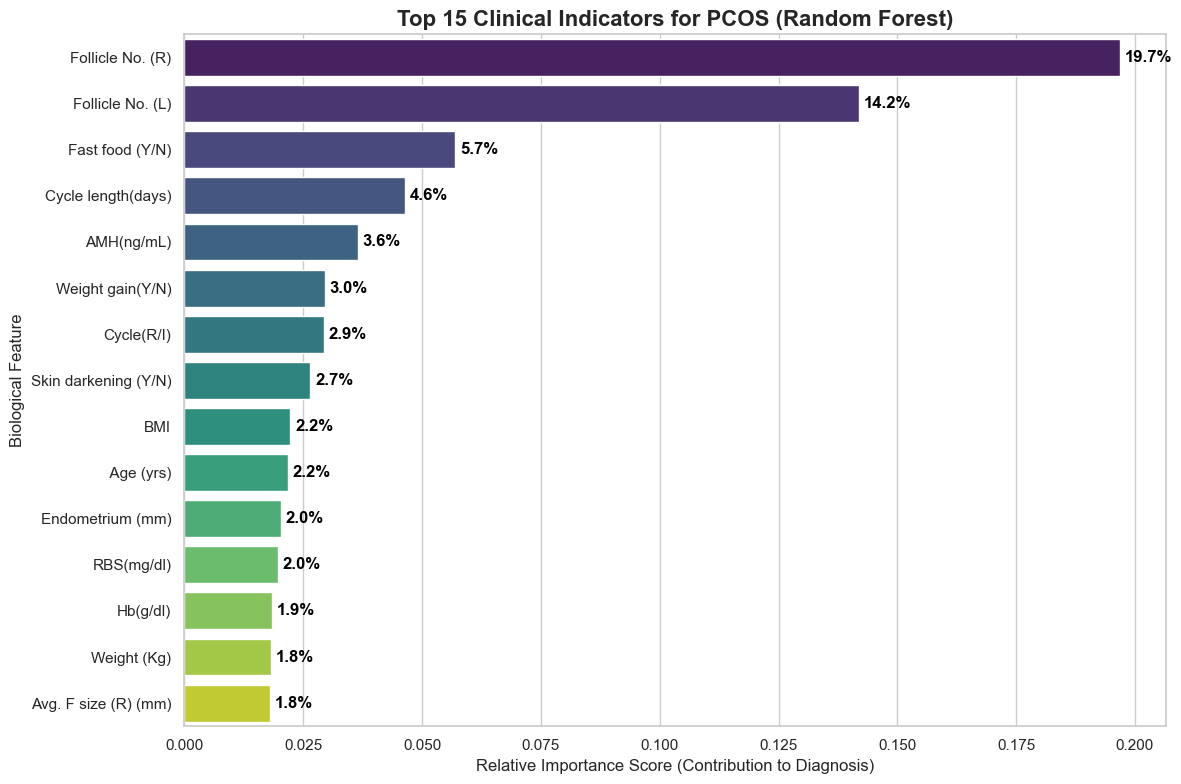

[*] Feature Importance extraction completed.


In [9]:
# Step 6: Feature Importance Extraction:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EXTRACTING CLINICAL FEATURE IMPORTANCE ---")

# 1. Extract the trained Random Forest model from our dictionary
rf_model = models["Random Forest"]

# 2. Extract the mathematical importance scores calculated by the trees
# The scores will always add up to 1.0 (100%)
importance_scores = rf_model.feature_importances_

# 3. Match the scores to the actual medical column names
feature_names = X_train_scaled.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
})

# 4. Sort the features from most important to least important
# We will only grab the Top 15 so the chart is easy to read
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 5. Generate a professional presentation chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')

# 6. Format the chart for clinical readability
plt.title('Top 15 Clinical Indicators for PCOS (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Score (Contribution to Diagnosis)', fontsize=12)
plt.ylabel('Biological Feature', fontsize=12)

# Add exact percentage text to the bars
for index, value in enumerate(top_15_features['Importance']):
    plt.text(value + 0.001, index, f"{value*100:.1f}%", va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("[*] Feature Importance extraction completed.")

In [11]:
# ==========================================
# PHASE 3: MODEL DEPLOYMENT
# ==========================================

# Step 1: Exporting the ML Engine & Scaler:

import joblib
import os

print("--- PHASE 3: MODEL EXPORT INITIALIZED ---")

# 1. Create a dedicated folder to keep your project organized
os.makedirs('deployed_models', exist_ok=True)

# 2. Extract our winning model (Random Forest)
best_model = models["Random Forest"]

# 3. Save the Model (The Brain)
model_path = 'deployed_models/pcos_rf_model.pkl'
joblib.dump(best_model, model_path)
print(f"[*] WINNING MODEL SAVED: {model_path}")

# 4. Save the Scaler (The Translator)
scaler_path = 'deployed_models/pcos_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"[*] FEATURE SCALER SAVED: {scaler_path}")

print("\n[*] Phase 3 Pipeline complete. Ready for full-stack integration.")

--- PHASE 3: MODEL EXPORT INITIALIZED ---
[*] WINNING MODEL SAVED: deployed_models/pcos_rf_model.pkl
[*] FEATURE SCALER SAVED: deployed_models/pcos_scaler.pkl

[*] Phase 3 Pipeline complete. Ready for full-stack integration.
